In [1]:
!pip install torch transformers peft trl accelerate datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 95.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.1/825.1 kB 35.7 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0

In [9]:
!pip install -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.1 MB/s eta 0:00:00:00:0100:01


In [4]:
import shutil, os

os.makedirs("data", exist_ok=True)
os.makedirs("training", exist_ok=True)

shutil.copy("/kaggle/input/datasets/subhranilmondal201/dataset/medical_qa.json", "data/medical_qa.json")
shutil.copy("/kaggle/input/datasets/subhranilmondal201/training-files/config.py", "training/config.py")
shutil.copy("/kaggle/input/datasets/subhranilmondal201/training-files/dataset.py", "training/dataset.py")
shutil.copy("/kaggle/input/datasets/subhranilmondal201/training-files/train.py", "training/train.py")

print("All files ready!")

All files ready!


In [14]:
!python training/train.py

Device: cuda
Loading tokenizer: Qwen/Qwen2.5-3B-Instruct
Loading model: Qwen/Qwen2.5-3B-Instruct
Loading weights: 100%|█| 434/434 [00:02<00:00, 202.27it/s, Materializing param=m
Configuring LoRA...
trainable params: 29,933,568 || all params: 3,115,872,256 || trainable%: 0.9607
Loading dataset from data/medical_qa.json...
Loaded 7321 training samples
Total training samples: 7321
/kaggle/working/training/train.py:54: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  training_config = SFTConfig(

Starting training...

In [16]:
import os

# Find trainer_state.json
for root, dirs, files in os.walk("results"):
    for f in files:
        if "trainer_state" in f:
            print(f"Found: {os.path.join(root, f)}")

# Also check what's in each checkpoint
for checkpoint in ["checkpoint-500", "checkpoint-1000", "checkpoint-1500", "checkpoint-2000", "checkpoint-2500"]:
    path = f"results/{checkpoint}"
    if os.path.exists(path):
        print(f"\n{checkpoint}/")
        for f in os.listdir(path):
            print(f"  {f}")

Found: results/checkpoint-1500/trainer_state.json
Found: results/checkpoint-1000/trainer_state.json
Found: results/checkpoint-500/trainer_state.json
Found: results/checkpoint-2748/trainer_state.json
Found: results/checkpoint-2000/trainer_state.json
Found: results/checkpoint-2500/trainer_state.json

checkpoint-500/
  adapter_model.safetensors
  optimizer.pt
  training_args.bin
  adapter_config.json
  scheduler.pt
  tokenizer_config.json
  chat_template.jinja
  README.md
  tokenizer.json
  rng_state.pth
  trainer_state.json

checkpoint-1000/
  adapter_model.safetensors
  optimizer.pt
  training_args.bin
  adapter_config.json
  scheduler.pt
  tokenizer_config.json
  chat_template.jinja
  README.md
  tokenizer.json
  rng_state.pth
  trainer_state.json

checkpoint-1500/
  adapter_model.safetensors
  optimizer.pt
  training_args.bin
  adapter_config.json
  scheduler.pt
  tokenizer_config.json
  chat_template.jinja
  README.md
  tokenizer.json
  rng_state.pth
  trainer_state.json

checkpoint-

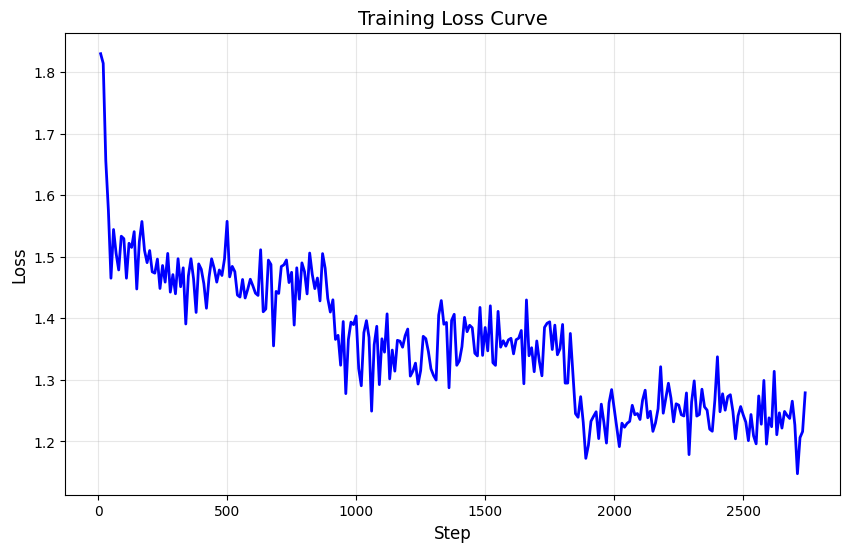

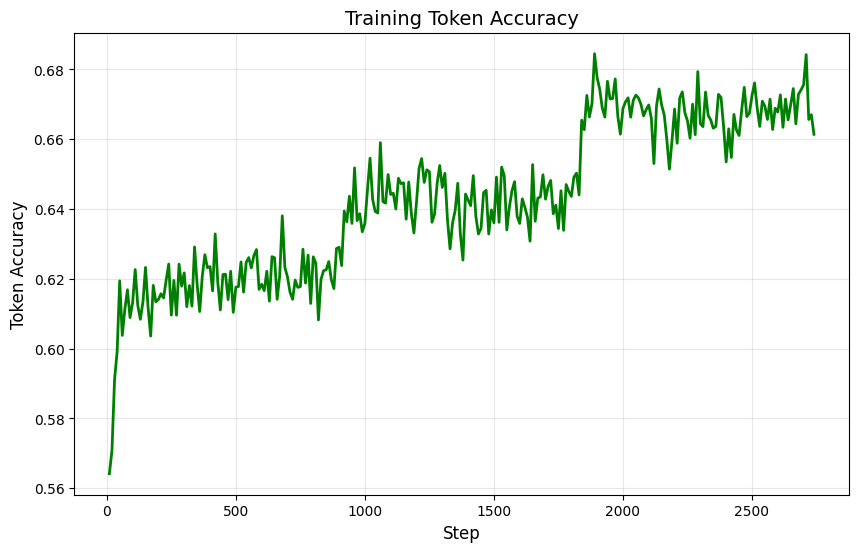

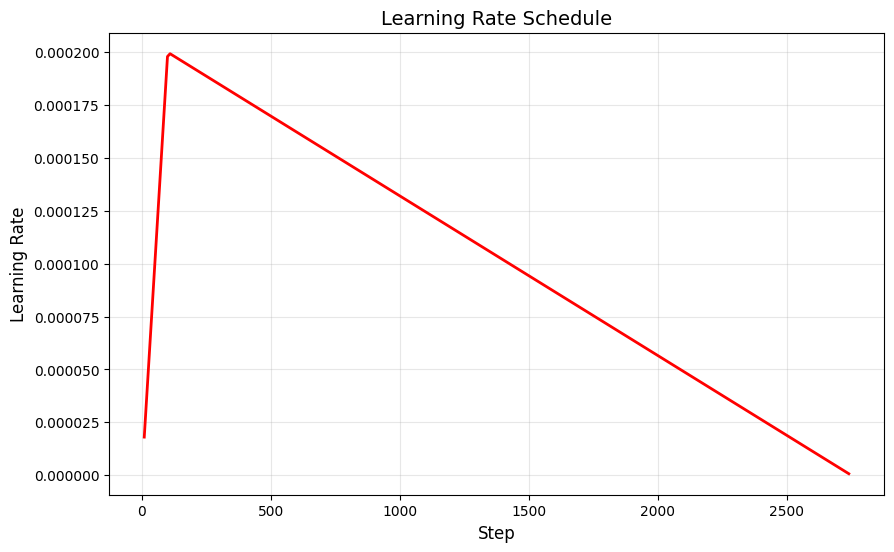

TRAINING SUMMARY
Final Loss: 1.2789
Best Loss: 1.1475
Final Accuracy: 0.6614
Best Accuracy: 0.6845
Total Steps: 2740
Epochs: 3.0


In [17]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Use the final checkpoint
log_file = "results/checkpoint-2748/trainer_state.json"

with open(log_file, 'r') as f:
    state = json.load(f)

logs = state['log_history']

# Parse logs
train_logs = [l for l in logs if 'loss' in l and 'eval_loss' not in l]

train_steps = [l['step'] for l in train_logs]
train_loss = [l['loss'] for l in train_logs]
train_acc = [l.get('mean_token_accuracy', None) for l in train_logs]
train_lr = [l.get('learning_rate', None) for l in train_logs]

# Plot 1: Training Loss
plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_loss, 'b-', linewidth=2)
plt.xlabel('Step', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training Loss Curve', fontsize=14)
plt.grid(True, alpha=0.3)
plt.savefig('plot_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Token Accuracy
plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_acc, 'g-', linewidth=2)
plt.xlabel('Step', fontsize=12)
plt.ylabel('Token Accuracy', fontsize=12)
plt.title('Training Token Accuracy', fontsize=14)
plt.grid(True, alpha=0.3)
plt.savefig('plot_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 3: Learning Rate
plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_lr, 'r-', linewidth=2)
plt.xlabel('Step', fontsize=12)
plt.ylabel('Learning Rate', fontsize=12)
plt.title('Learning Rate Schedule', fontsize=14)
plt.grid(True, alpha=0.3)
plt.savefig('plot_lr.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("=" * 50)
print("TRAINING SUMMARY")
print("=" * 50)
print(f"Final Loss: {train_loss[-1]:.4f}")
print(f"Best Loss: {min(train_loss):.4f}")
print(f"Final Accuracy: {train_acc[-1]:.4f}")
print(f"Best Accuracy: {max(train_acc):.4f}")
print(f"Total Steps: {train_steps[-1]}")
print(f"Epochs: {state.get('epoch', 'N/A')}")

In [18]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
import json
import random

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-3B-Instruct",
    quantization_config=bnb_config,
    device_map="auto",
)

print("Loading LoRA adapter...")
model = PeftModel.from_pretrained(base_model, "results/checkpoint-2748")
model.eval()

tokenizer = AutoTokenizer.from_pretrained("results/checkpoint-2748")

# Load test data
with open("data/medical_qa.json", "r") as f:
    data = json.load(f)

random.seed(42)
test_samples = random.sample(data, 20)

predictions = []
references = []

print("\nGenerating responses...")
for i, sample in enumerate(test_samples):
    prompt = f"Medical Question: {sample['input']}\nAnswer:"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=256,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    generated = response[len(prompt):].strip()
    
    predictions.append(generated)
    references.append(sample['answer_chatgpt'])
    
    if (i + 1) % 5 == 0:
        print(f"  {i+1}/20 done")

print("Generation complete!")

Loading base model...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Loading LoRA adapter...

Generating responses...
  5/20 done
  10/20 done
  15/20 done
  20/20 done
Generation complete!


EVALUATION METRICS
ROUGE-1:  0.4972 (+/- 0.0676)
ROUGE-2:  0.1717 (+/- 0.0645)
ROUGE-L:  0.2660 (+/- 0.0645)
BLEU:     0.0883 (+/- 0.0541)


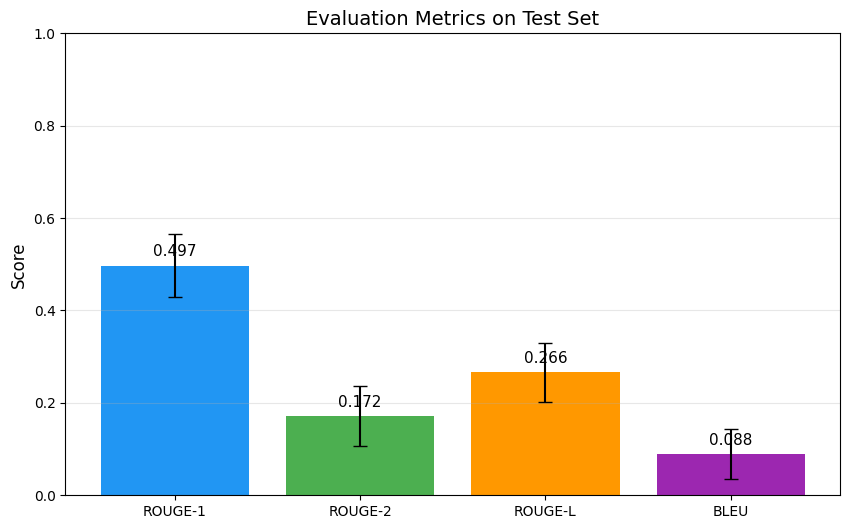

In [19]:
!pip install rouge-score nltk -q

from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
smoother = SmoothingFunction().method1

rouge1, rouge2, rougeL, bleu = [], [], [], []

for pred, ref in zip(predictions, references):
    scores = scorer.score(ref, pred)
    rouge1.append(scores['rouge1'].fmeasure)
    rouge2.append(scores['rouge2'].fmeasure)
    rougeL.append(scores['rougeL'].fmeasure)
    bleu.append(sentence_bleu([ref.split()], pred.split(), smoothing_function=smoother))

print("=" * 60)
print("EVALUATION METRICS")
print("=" * 60)
print(f"ROUGE-1:  {np.mean(rouge1):.4f} (+/- {np.std(rouge1):.4f})")
print(f"ROUGE-2:  {np.mean(rouge2):.4f} (+/- {np.std(rouge2):.4f})")
print(f"ROUGE-L:  {np.mean(rougeL):.4f} (+/- {np.std(rougeL):.4f})")
print(f"BLEU:     {np.mean(bleu):.4f} (+/- {np.std(bleu):.4f})")
print("=" * 60)

# Bar chart
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BLEU']
values = [np.mean(rouge1), np.mean(rouge2), np.mean(rougeL), np.mean(bleu)]
errors = [np.std(rouge1), np.std(rouge2), np.std(rougeL), np.std(bleu)]

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, yerr=errors, capsize=5, color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'])
plt.ylabel('Score', fontsize=12)
plt.title('Evaluation Metrics on Test Set', fontsize=14)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', ha='center', fontsize=11)

plt.savefig('plot_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
for i in range(5):
    print(f"\n--- Sample {i+1} ---")
    print(f"Q: {test_samples[i]['input'][:120]}...")
    print(f"Ref: {references[i][:150]}...")
    print(f"Gen: {predictions[i][:150]}...")


--- Sample 1 ---
Q: Hi doctor,I am a 28 year old unmarried woman. Last month my period was irregular. I got my periods on the 30th of last m...
Ref: Hello! It sounds like you are experiencing some irregular bleeding, which can certainly be concerning. There are many potential causes of irregular bl...
Gen: Hello,

Irregular periods can be caused by many factors such as stress, weight changes, hormonal imbalances, thyroid problems, polycystic ovary syndro...

--- Sample 2 ---
Q: Hello doctor,So I never had acne on the back, maybe one or two single, but after visiting this massage center, which I k...
Ref: Hello! It sounds like you may have developed a condition called acne mechanica, which is caused by friction, pressure, or rubbing against the skin. It...
Gen: Hello! I'm sorry to hear that you're dealing with acne on your back. It's important to note that using massage centers or other establishments that in...

--- Sample 3 ---
Q: Hello doctor,I want to lose my weight. I am very obse

In [21]:
!zip -r plots.zip plot_loss.png plot_accuracy.png plot_lr.png plot_metrics.png
from IPython.display import FileLink
FileLink('plots.zip')

  adding: plot_loss.png (deflated 9%)
  adding: plot_accuracy.png (deflated 8%)
  adding: plot_lr.png (deflated 16%)
  adding: plot_metrics.png (deflated 25%)


/kaggle/working/plots.zip

In [22]:
import shutil
from IPython.display import FileLink

# Show what's in results
!ls -la results/

# Download the final adapter (not checkpoints)
!zip -r results.zip results/adapter_model.safetensors results/adapter_config.json results/tokenizer.json results/tokenizer_config.json results/special_tokens_map.json

# Create download link
FileLink('results.zip')

total 69744
drwxr-xr-x 8 root root     4096 Jun 24 12:42 .
drwxr-xr-x 6 root root     4096 Jun 24 13:08 ..
-rw-r--r-- 1 root root     1054 Jun 24 12:42 adapter_config.json
-rw-r--r-- 1 root root 59934640 Jun 24 12:42 adapter_model.safetensors
-rw-r--r-- 1 root root     2507 Jun 24 12:42 chat_template.jinja
drwxr-xr-x 2 root root     4096 Jun 24 07:07 checkpoint-1000
drwxr-xr-x 2 root root     4096 Jun 24 08:43 checkpoint-1500
drwxr-xr-x 2 root root     4096 Jun 24 10:19 checkpoint-2000
drwxr-xr-x 2 root root     4096 Jun 24 11:55 checkpoint-2500
drwxr-xr-x 2 root root     4096 Jun 24 12:42 checkpoint-2748
drwxr-xr-x 2 root root     4096 Jun 24 05:32 checkpoint-500
-rw-r--r-- 1 root root     1467 Jun 24 12:42 README.md
-rw-r--r-- 1 root root      662 Jun 24 12:42 tokenizer_config.json
-rw-r--r-- 1 root root 11421892 Jun 24 12:42 tokenizer.json
-rw-r--r-- 1 root root     5585 Jun 24 12:42 training_args.bin
	zip warning: name not matched: results/special_tokens_map.json
  adding: results/

/kaggle/working/results.zip